In [2]:
import pandas as pd
import duckdb
from datetime import datetime
from dateutil import relativedelta
import logging

path = r'C:\Users\HN34064\Documents\2026\6. Junio\1. PD Honduras\Data\Detalle'

path = path.replace('\\','/')

In [14]:
print(datetime.now())
query = f"""
select anio_mes, count(1) as conteo
from read_csv_auto('{path}/*.csv')
group by anio_mes
order by 1 asc
"""

result = duckdb.execute(query=query).fetch_df()
print(datetime.now())
result.head(2)

2026-06-22 09:15:59.737269
2026-06-22 09:16:06.467444


,ANIO_MES,conteo
0,2021-04-30,372850
1,2021-05-31,378502


In [24]:
result['ANIO_MES'].dt.year.value_counts()

ANIO_MES
2022    12
2023    12
2024    12
2025    12
2021     9
2026     4
Name: count, dtype: int64

In [33]:
from datetime import date
from dateutil.relativedelta import relativedelta

hoy = date.today()
print(hoy)

#This gets the last_day for the current 
hoy.replace(day=1) + relativedelta(months=1,days=-1)

#Get all end months until the end of the year
last_end_month =hoy.replace(month=1,day=1) + relativedelta(years=1,days=-1)




2026-06-22


In [ ]:
diff = relativedelta(last_end_month, hoy)
traveler = date
for i in range(diff.months+1):
    print(hoy.replace(day=1) + relativedelta(months=i+1,days=-1))


2026-06-30
2026-07-31
2026-08-31
2026-09-30
2026-10-31
2026-11-30
2026-12-31


In [55]:
traveler=hoy.replace(day=1) + relativedelta(months=1,days=-1)
while traveler<=last_end_month:
    print(traveler)
    traveler = traveler + relativedelta(months=2, day=1,days=-1)


2026-06-30
2026-07-31
2026-08-31
2026-09-30
2026-10-31
2026-11-30
2026-12-31


In [ ]:
import pyodbc as odbc

server='andromeda'
database = 'MIS_RIESGOS'
connection_string = f"""
DRIVER={{ODBC Driver 17 for SQL Server}};
SERVER={server}; DATABASE={database};
Trusted_Connection=yes;
"""

In [ ]:
query='select getdate() as fecha'
connection=odbc.connect(connection_string)
df = pd.read_sql(sql=query,con=connection)
connection.close()
df.head()

C:\Users\HN34064\AppData\Local\Temp\ipykernel_7648\944877764.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql=query,con=connection)


,fecha
0,2026-06-22 10:17:48


In [94]:

con = odbc.connect(connection_string)

In [95]:
cursor1 = con.cursor()

In [96]:
query="""
SELECT ANIO_MES, count(1) as conteo
            FROM MIS_RIESGOS.RIESGOS.HN_BASE_PROBABILIDADES_DEFAULT_SII
            group by anio_mes
"""
result = cursor1.execute(query)

In [97]:
drop = result.fetchall()

In [100]:
cursor1.close()
con.close()

In [98]:
df = pd.DataFrame.from_records(drop, columns = ['fecha','conteo'])
df.sort_values(by=['fecha'], ascending=True, inplace=True)

In [104]:
df['fecha'].dt.year.value_counts()

fecha
2022    12
2023    12
2024    12
2025    12
2021     9
2026     4
Name: count, dtype: int64

In [130]:
import pyodbc as odbc
import pandas as pd

server='andromeda'
database = 'MIS_RIESGOS'
connection_string=f"""
DRIVER={{ODBC Driver 17 for SQL Server}};
SERVER={server};
DATABASE={database};
Trusted_Connection=yes;
"""

query = """
SELECT
	SEGMENTO, 
    CLASIFICACION_MAXIMA_ANTERIOR,
	CLASIFICACION_MAXIMA_ACTUAL, 
	COUNT(OBLIGACION) AS CONTEO,
	SUM(SALDO_ANTERIOR) AS SALDO
FROM RIESGOS.HN_TRANCISIONES_MATRICES_MARKOV_SII
GROUP BY SEGMENTO, 
    CLASIFICACION_MAXIMA_ANTERIOR,
	CLASIFICACION_MAXIMA_ACTUAL
;
"""

con = odbc.connect(connection_string)
cursor1 = con.cursor()
result = cursor1.execute(query)
result = result.fetchall()

df = pd.DataFrame.from_records(result,columns=['SEGMENTO','CLASIFICACION_MAXIMA_ANTERIOR','CLASIFICACION_MAXIMA_ACTUAL','CONTEO','SALDO'])

In [131]:
cursor1.close()
con.close()

In [132]:
output_path = r'C:\Users\HN34064\Documents\2026\6. Junio\1. PD Honduras\Data'
output_path = output_path.replace('\\','/')

df.to_excel(output_path+'/HN_Sumarizado_II.xlsx', index=False, header=True,sheet_name='Data')

In [115]:
import pyodbc as odbc
import pandas as pd
from datetime import datetime
print(datetime.now())

server='andromeda'
database='MIS_RIESGOS'
connection_string=f"""
DRIVER={{ODBC Driver 17 for SQL Server}};
SERVER={server};
DATABASE={database};
Trusted_Connection=yes;
"""

con = odbc.connect(connection_string)
cursor = con.cursor()
query = """
SELECT ANIO_MES, count(1) as conteo
            FROM MIS_RIESGOS.RIESGOS.HN_BASE_PROBABILIDADES_DEFAULT_SII
            group by anio_mes
"""
result = cursor.execute(query)
result = result.fetchall()

cursor.close()
con.close()
print(datetime.now())

2026-06-22 11:02:52.863642
2026-06-22 11:03:18.815251


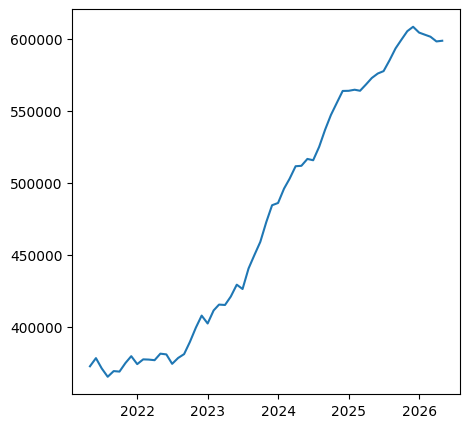

In [ ]:
from matplotlib import pyplot as plt

df = pd.DataFrame.from_records(result, columns = ['fecha','conteo'])

df.sort_values(by=['fecha'],ascending=True,inplace=True)
df.set_index('fecha',inplace=True)

fig, ax = plt.subplots(figsize=(5,5))
ax.plot(df)

plt.show()